# DeepSeek-V4-Flash-Vision-Exp — 4-card PP4 vLLM concurrency ladder

Measured 2026-09-02 on 4x NVIDIA CMP 170HX (SM80, 64 GiB each). Text-only
decode and prefill benchmark of `deepseek-ai/DeepSeek-V4-Flash-Vision-Exp`
on the SM80 vLLM fork, pipeline parallel 4, DSpark speculative decoding.

This is a **text-path performance** result. Vision correctness on this
checkpoint was measured on a different runtime and is not comparable to
the numbers here. See the vision notebook and Section 4.

Reading order: TL;DR, then visible results, then reproduce steps. The
appendix at the end holds the failure history and preflight detail.

Evidence source: `results/2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm/`.
Related: [DeepSeek-V4-Flash-Vision-Exp-CMP-170HX PR #5](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX/pull/5),
[HF collection: club-170hx verified on CMP 170HX (SM80)](https://huggingface.co/collections/PixelML/club-170hx-verified-on-cmp-170hx-sm80-6a97bf4edc20b52c5cf454e3).


In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/<experiment>/.
# LIVE = True runs the same harness against a running OpenAI-compatible
# endpoint whose URL comes from an environment variable. Never hardcode an
# endpoint address in this notebook.
import os

EXPERIMENT = "2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm"
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
ENDPOINT_ENV_VAR = "DSV4_URL"  # set this env var before running with LIVE = True

print(f"experiment   : {EXPERIMENT}")
print(f"results_dir  : {RESULTS_DIR}")
print(f"LIVE         : {LIVE}")
if LIVE:
    endpoint = os.environ.get(ENDPOINT_ENV_VAR)
    if not endpoint:
        raise RuntimeError(f"LIVE=True but {ENDPOINT_ENV_VAR} is not set")
    print(f"endpoint     : from ${ENDPOINT_ENV_VAR} (not printed)")
else:
    print("endpoint     : n/a (replaying committed receipts)")


experiment   : 2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm
results_dir  : ../results/2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm
LIVE         : False
endpoint     : n/a (replaying committed receipts)


In [2]:
# --- Helper: receipt loader ---------------------------------------------
import json
import os


def load_receipt(name, results_dir=RESULTS_DIR):
    """Load one JSON receipt from results_dir. Raises if missing."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return json.load(f)


def load_text(name, results_dir=RESULTS_DIR):
    """Load one text/markdown receipt from results_dir."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return f.read()


def load_csv_rows(name, results_dir=RESULTS_DIR):
    """Load a telemetry CSV as a list of raw lines."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return f.read().splitlines()


summary = load_receipt("summary.json")
gate = load_receipt("gate.json")
prefill = load_receipt("prefill.json")
ttft = load_receipt("ttft.json")
ladder = load_receipt("ladder.json")
print("loaded: summary.json, gate.json, prefill.json, ttft.json, ladder.json")


loaded: summary.json, gate.json, prefill.json, ttft.json, ladder.json


In [3]:
# --- Helper: table renderer ----------------------------------------------
from IPython.display import display, Markdown


def render_table(headers, rows):
    """Render a list-of-lists as a Markdown table with the given headers.
    Every header carries its unit, e.g. 'Decode (tok/s)'."""
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))


## 1. TL;DR

Text-path decode and prefill benchmark. PASS through concurrency 8;
concurrency 16 fails on its first measured repetition. No image input
was sent in this notebook. Vision correctness on this checkpoint is a
separate result on a separate runtime, in
`2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm.ipynb`.


In [4]:
# Values match the ladder/prefill/ttft/summary receipts loaded above;
# spelled out here (rather than re-derived) so the TL;DR table renders
# even if a later section's parsing changes.
key_metrics = [
    ("Overall verdict", "PASS, c=1 through c=8; c=16 FAIL (device-side assert)"),
    ("Decode, c=1 (median of 3, tok/s)", 97.41),
    ("Aggregate decode, c=4 (median of 3, tok/s)", 165.53),
    ("Aggregate decode, c=8 (median of 3, tok/s)", 220.17),
    ("Uncached prefill, 2,941 tokens, warm (tok/s)", 2352.24),
    ("Warm streaming TTFT, 2,941-token fixture (s)", 0.394),
    ("Cold boot to ready (min)", 41.9),
    ("KV cache dtype", "fp8"),
    ("Speculative decoding", "DSpark, k=6"),
]
render_table(["Metric", "Value"], key_metrics)


| Metric | Value |
|---|---|
| Overall verdict | PASS, c=1 through c=8; c=16 FAIL (device-side assert) |
| Decode, c=1 (median of 3, tok/s) | 97.41 |
| Aggregate decode, c=4 (median of 3, tok/s) | 165.53 |
| Aggregate decode, c=8 (median of 3, tok/s) | 220.17 |
| Uncached prefill, 2,941 tokens, warm (tok/s) | 2352.24 |
| Warm streaming TTFT, 2,941-token fixture (s) | 0.394 |
| Cold boot to ready (min) | 41.9 |
| KV cache dtype | fp8 |
| Speculative decoding | DSpark, k=6 |

### Pins

All values below are read from `summary.json`, the launch command, and the
build receipts in the evidence bundle. Torch and vLLM do not report a pip
semver in this build (source build from a fork commit, not a package
install); the engine's own log banner reports internal build tag `v0.0.0`.
That absence is stated here rather than guessed.


In [5]:
pins = [
    ("Model", summary["model"]),
    ("Revision", summary["revision"]),
    ("Safetensors shards", summary["snapshot"]["safetensors_shards"]),
    ("num_nextn_predict_layers (MTP/draft heads)", summary["snapshot"]["num_nextn_predict_layers"]),
    ("num_hidden_layers", summary["snapshot"]["num_hidden_layers"]),
    ("Snapshot verification", summary["snapshot"]["verdict"] + " (repo bytes match: " + str(summary["snapshot"]["repo_bytes_match"]) + ")"),
    ("Image digest", summary["image"]["id"]),
    ("Image build", summary["image"]["build"]),
    ("Runtime source", summary["image"]["source"]),
    ("Fork lineage", "allover326/vllm-dsa-mtp-sm80 base + SM80 patches (8 files, receipts/vllm-source-patches.diff)"),
    ("TORCH_CUDA_ARCH_LIST", "8.0 (SM80)"),
    ("Torch / vLLM package version", "not captured as a pip semver in receipts (source build); engine log reports internal build tag v0.0.0"),
    ("Topology", "Pipeline-parallel 4, layer partition 11,11,11,10 (VLLM_PP_LAYER_PARTITION)"),
    ("Speculative decoding", "DSpark, num_speculative_tokens=6 (k=6)"),
    ("KV cache dtype", "fp8"),
    ("Hardware", "4x CMP 170HX, SM80, 64 GiB each, 180 W power limit each"),
]
render_table(["Pin", "Value"], pins)


| Pin | Value |
|---|---|
| Model | deepseek-ai/DeepSeek-V4-Flash-Vision-Exp |
| Revision | 86f746b36186f0e567729a5c06a8c918caba82a9 |
| Safetensors shards | 48 |
| num_nextn_predict_layers (MTP/draft heads) | 3 |
| num_hidden_layers | 43 |
| Snapshot verification | PASS (repo bytes match: True) |
| Image digest | sha256:90a1419e8ceaad3542153ef4e2a1d94a69b9af03cce7b0a1b267dd1dad55b9d7 |
| Image build | all layers cache-hit (image created 2026-09-01T05:22:44Z) |
| Runtime source | <workdir>/repos/dsv4-vllm @ f8ea5bb163c161ef38b401d055cc5fd4a934091a + 8 uncommitted patch files (receipts/vllm-source-patches.diff) |
| Fork lineage | allover326/vllm-dsa-mtp-sm80 base + SM80 patches (8 files, receipts/vllm-source-patches.diff) |
| TORCH_CUDA_ARCH_LIST | 8.0 (SM80) |
| Torch / vLLM package version | not captured as a pip semver in receipts (source build); engine log reports internal build tag v0.0.0 |
| Topology | Pipeline-parallel 4, layer partition 11,11,11,10 (VLLM_PP_LAYER_PARTITION) |
| Speculative decoding | DSpark, num_speculative_tokens=6 (k=6) |
| KV cache dtype | fp8 |
| Hardware | 4x CMP 170HX, SM80, 64 GiB each, 180 W power limit each |

In [6]:
from IPython.display import Video
Video(url="../assets/video/dsv4-vision-4card-motion/dsv4-vision-4card-motion-1080x1920.mp4", embed=False, html_attributes="controls loop muted playsinline")


If the player above does not load: [dsv4-vision-4card-motion-1080x1920.mp4](../assets/video/dsv4-vision-4card-motion/dsv4-vision-4card-motion-1080x1920.mp4).

![poster frame](../assets/video/dsv4-vision-4card-motion/dsv4-vision-4card-motion-poster.png)


## 2. Visible results

The load gate, the functional-gate protocol, and every measurement table
and chart. Numbers come from the receipts in
`results/2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm/`.


### 2.1 Load gate


In [7]:
gate_rows = [
    (i, r["ok"], r["wall_s"], r["usage"]["completion_tokens"], repr(r["text_head"]), r["finish_reason"])
    for i, r in enumerate(gate["deterministic_reps"])
]
render_table(["Rep", "OK", "Wall time (s)", "Completion tokens", "Text", "Finish reason"], gate_rows)
print("Gate verdict:", gate["verdict"], "| identical across reps:", gate["deterministic_identical"])


| Rep | OK | Wall time (s) | Completion tokens | Text | Finish reason |
|---|---|---|---|---|---|
| 0 | True | 0.3497 | 1 | ' Paris' | length |
| 1 | True | 0.2903 | 1 | ' Paris' | length |
| 2 | True | 0.2913 | 1 | ' Paris' | length |

Gate verdict: PASS | identical across reps: True


### 2.2 Functional gate protocol


In [8]:
functional_gates = [
    ("Sampling", "greedy, temperature=0"),
    ("Ladder completion tokens per request", ladder["max_tokens"]),
    ("Ladder concurrency levels", [lvl["concurrency"] for lvl in ladder["levels"]]),
    ("Warmup reps per level", ladder["warmup_per_level"]),
    ("Measured reps per level", ladder["measured_reps_per_level"]),
    ("Prefill fixture prompt tokens", prefill["target_prompt_tokens"]),
    ("Prefill fixture prompt_tokens_exact (tokenizer verified)", prefill["prompt_tokens_exact"]),
    ("TTFT fixture prompt tokens", ttft["fixture_tokens"]),
]
render_table(["Gate", "Value"], functional_gates)


| Gate | Value |
|---|---|
| Sampling | greedy, temperature=0 |
| Ladder completion tokens per request | 400 |
| Ladder concurrency levels | [1, 2, 4, 8, 16] |
| Warmup reps per level | 1 |
| Measured reps per level | 3 |
| Prefill fixture prompt tokens | 2941 |
| Prefill fixture prompt_tokens_exact (tokenizer verified) | True |
| TTFT fixture prompt tokens | 2941 |

### 2.3 Measurements

#### Uncached prefill (2,941 input tokens, max_tokens=1)

In [9]:
prefill_rows = [
    (i, r["ok"], r["wall_s"], r["prefill_tok_s"], "first cold prefill after boot" if i == 0 else "warm")
    for i, r in enumerate(prefill["reps"])
]
render_table(["Rep", "OK", "Wall time (s)", "Prefill throughput (tok/s)", "Note"], prefill_rows)
print(f"Median warm prefill: {prefill['median_wall_s']} s / {prefill['median_prefill_tok_s']} tok/s")
print("(rep0 is the cold, first-after-boot prefill and is excluded from the warm median)")


| Rep | OK | Wall time (s) | Prefill throughput (tok/s) | Note |
|---|---|---|---|---|
| 0 | True | 8.1295 | 361.77 | first cold prefill after boot |
| 1 | True | 1.2503 | 2352.24 | warm |
| 2 | True | 1.2181 | 2414.42 | warm |

Median warm prefill: 1.2503 s / 2352.24 tok/s
(rep0 is the cold, first-after-boot prefill and is excluded from the warm median)


### 5.2 Warm streaming TTFT (same 2,941-token fixture, prefix cached)

In [10]:
ttft_rows = [
    (i, r["ok"], r["ttft_s"], r["total_s"], r["usage"]["completion_tokens"])
    for i, r in enumerate(ttft["reps"])
]
render_table(["Rep", "OK", "TTFT (s)", "Total request time (s)", "Completion tokens"], ttft_rows)
print(f"Median TTFT: {ttft['median_ttft_s']} s")


| Rep | OK | TTFT (s) | Total request time (s) | Completion tokens |
|---|---|---|---|---|
| 0 | True | 0.3885 | 1.7433 | 32 |
| 1 | True | 0.3936 | 0.6032 | 32 |
| 2 | True | 0.4182 | 0.632 | 32 |

Median TTFT: 0.3936 s


### 5.3 Concurrency ladder — aggregate throughput

Aggregate tok/s = sum of `usage.completion_tokens` across all requests in a
repetition, divided by the synchronized wall time of that repetition. C16
warmup passed (16/16); the first measured repetition lost all 16 requests
to a device-side assert on rank 3 in the draft path and the level is
recorded as failed, not retried.

In [11]:
agg_rows = []
for lvl in ladder["levels"]:
    c = lvl["concurrency"]
    reps = lvl["reps"]
    aggs = [r["aggregate_tok_s"] for r in reps if r["succeeded"] == r["requests"]]
    if aggs:
        aggs_sorted = sorted(aggs)
        median = aggs_sorted[len(aggs_sorted) // 2] if len(aggs_sorted) % 2 else \
            (aggs_sorted[len(aggs_sorted)//2 - 1] + aggs_sorted[len(aggs_sorted)//2]) / 2
        agg_rows.append((c, f"{median:.2f}", f"{min(aggs):.2f}", f"{max(aggs):.2f}",
                          sum(r["succeeded"] for r in reps), sum(r["requests"] for r in reps), "PASS"))
    else:
        total_req = sum(r["requests"] for r in reps)
        total_ok = sum(r["succeeded"] for r in reps)
        agg_rows.append((c, "n/a", "n/a", "n/a", total_ok, total_req, "FAIL (device-side assert, rank 3 draft path)"))

render_table(
    ["Concurrency (requests)", "Aggregate median (tok/s)", "Aggregate min (tok/s)",
     "Aggregate max (tok/s)", "Requests succeeded", "Requests sent", "Status"],
    agg_rows,
)


| Concurrency (requests) | Aggregate median (tok/s) | Aggregate min (tok/s) | Aggregate max (tok/s) | Requests succeeded | Requests sent | Status |
|---|---|---|---|---|---|---|
| 1 | 97.41 | 57.58 | 123.45 | 3 | 3 | PASS |
| 2 | 103.66 | 96.58 | 159.24 | 6 | 6 | PASS |
| 4 | 165.53 | 140.32 | 203.17 | 12 | 12 | PASS |
| 8 | 220.17 | 206.33 | 231.99 | 24 | 24 | PASS |
| 16 | n/a | n/a | n/a | 0 | 16 | FAIL (device-side assert, rank 3 draft path) |

### 5.4 Concurrency ladder — per-request throughput

Per-request tok/s is the completion-token rate of one request inside a
repetition, so it falls as concurrency rises even while aggregate
throughput climbs — more requests are sharing the same four cards.

In [12]:
per_req_rows = []
for lvl in ladder["levels"]:
    c = lvl["concurrency"]
    all_vals = []
    for r in lvl["reps"]:
        if r["succeeded"] == r["requests"]:
            all_vals.extend(r["per_request_tok_s"]["all"])
    if all_vals:
        all_sorted = sorted(all_vals)
        n = len(all_sorted)
        median = all_sorted[n // 2] if n % 2 else (all_sorted[n//2 - 1] + all_sorted[n//2]) / 2
        per_req_rows.append((c, f"{median:.2f}", f"{min(all_vals):.2f}", f"{max(all_vals):.2f}", n))
    else:
        per_req_rows.append((c, "n/a", "n/a", "n/a", 0))

render_table(
    ["Concurrency (requests)", "Per-request median (tok/s)", "Per-request min (tok/s)",
     "Per-request max (tok/s)", "Successful requests measured"],
    per_req_rows,
)


| Concurrency (requests) | Per-request median (tok/s) | Per-request min (tok/s) | Per-request max (tok/s) | Successful requests measured |
|---|---|---|---|---|
| 1 | 97.42 | 57.58 | 123.47 | 3 |
| 2 | 56.85 | 48.30 | 106.51 | 6 |
| 4 | 60.77 | 35.08 | 104.07 | 12 |
| 8 | 37.29 | 25.80 | 62.76 | 24 |
| 16 | n/a | n/a | n/a | 0 |

### 5.5 Chart: throughput vs. concurrency

Aggregate throughput (sum across requests) and per-request throughput
(single-request rate), both in tokens/second, against concurrency
(number of simultaneous requests). C16 is shown as a labeled failure with
no plotted point, not as a zero.

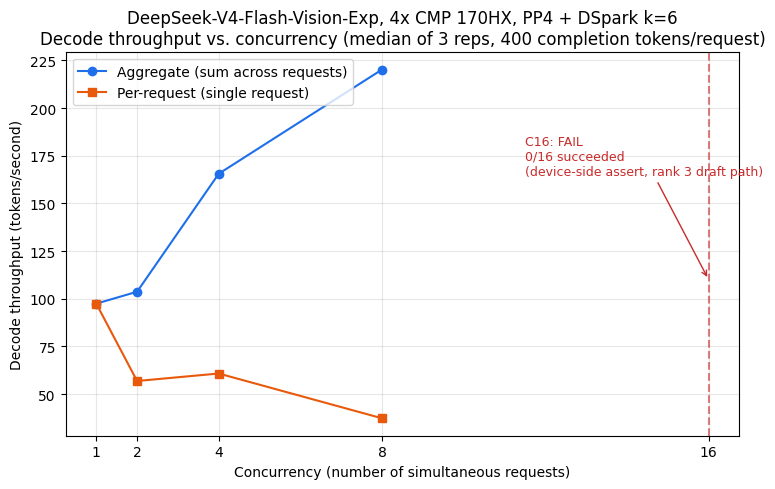

saved: assets/charts/2026-09-02-dsv4-vision-exp-4card-ladder.{png,svg}


In [13]:
import matplotlib.pyplot as plt

pass_levels = [row[0] for row in agg_rows if row[-1] == "PASS"]
agg_medians = [float(row[1]) for row in agg_rows if row[-1] == "PASS"]
per_req_medians = [float(row[1]) for row in per_req_rows if row[0] in pass_levels]

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(pass_levels, agg_medians, marker="o", color="#1f6feb", label="Aggregate (sum across requests)")
ax1.plot(pass_levels, per_req_medians, marker="s", color="#e8590c", label="Per-request (single request)")

# C16: labeled failure, no point plotted.
ax1.axvline(16, color="#c92a2a", linestyle="--", alpha=0.6)
ax1.annotate(
    "C16: FAIL\n0/16 succeeded\n(device-side assert, rank 3 draft path)",
    xy=(16, max(agg_medians) * 0.5),
    xytext=(11.5, max(agg_medians) * 0.75),
    fontsize=9, color="#c92a2a",
    arrowprops=dict(arrowstyle="->", color="#c92a2a"),
)

ax1.set_xlabel("Concurrency (number of simultaneous requests)")
ax1.set_ylabel("Decode throughput (tokens/second)")
ax1.set_title("DeepSeek-V4-Flash-Vision-Exp, 4x CMP 170HX, PP4 + DSpark k=6\nDecode throughput vs. concurrency (median of 3 reps, 400 completion tokens/request)")
ax1.set_xticks([1, 2, 4, 8, 16])
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")
fig.tight_layout()

import os
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig("../assets/charts/2026-09-02-dsv4-vision-exp-4card-ladder.png", dpi=150)
fig.savefig("../assets/charts/2026-09-02-dsv4-vision-exp-4card-ladder.svg")
plt.show()
print("saved: assets/charts/2026-09-02-dsv4-vision-exp-4card-ladder.{png,svg}")


### 5.6 Telemetry summary

Computed from `telemetry-5s.csv` (627 five-second `nvidia-smi` samples
across the full run, one line per timestamp, four cards per line).

In [14]:
import re

lines = load_csv_rows("telemetry-5s.csv")
per_card = {0: {"power": [], "temp": [], "mem": []},
            1: {"power": [], "temp": [], "mem": []},
            2: {"power": [], "temp": [], "mem": []},
            3: {"power": [], "temp": [], "mem": []}}

card_re = re.compile(r"(\d+),\s*([\d.]+)\s*W,\s*(\d+),\s*(\d+)\s*%,\s*(\d+)\s*MiB")

for line in lines:
    for idx, power, temp, util, mem in card_re.findall(line):
        idx = int(idx)
        per_card[idx]["power"].append(float(power))
        per_card[idx]["temp"].append(int(temp))
        per_card[idx]["mem"].append(int(mem))

telemetry_rows = []
for idx in range(4):
    p, t, m = per_card[idx]["power"], per_card[idx]["temp"], per_card[idx]["mem"]
    telemetry_rows.append((
        f"GPU {idx}",
        f"{min(p):.1f} - {max(p):.1f}",
        f"{min(t)} - {max(t)}",
        f"{min(m):,} - {max(m):,}",
    ))

render_table(
    ["Card", "Power range (W, 5 s samples, run duration)", "Core temp range (C, 5 s samples)",
     "Memory used range (MiB, 5 s samples, of 65,536 MiB)"],
    telemetry_rows,
)
print("Samples:", len(lines), "| max core temp observed:", max(max(per_card[i]["temp"]) for i in range(4)), "C")
print("Note: instantaneous 2 s in-ladder samples in ladder.json show brief peaks above the 180 W/card averaged cap (up to ~241 W); the averaged power policy is 180 W/card.")


| Card | Power range (W, 5 s samples, run duration) | Core temp range (C, 5 s samples) | Memory used range (MiB, 5 s samples, of 65,536 MiB) |
|---|---|---|---|
| GPU 0 | 34.1 - 206.1 | 40 - 65 | 0 - 51,308 |
| GPU 1 | 38.2 - 210.6 | 39 - 63 | 0 - 50,276 |
| GPU 2 | 34.4 - 208.0 | 40 - 63 | 0 - 51,836 |
| GPU 3 | 36.0 - 216.9 | 39 - 62 | 0 - 60,576 |

Samples: 627 | max core temp observed: 65 C
Note: instantaneous 2 s in-ladder samples in ladder.json show brief peaks above the 180 W/card averaged cap (up to ~241 W); the averaged power policy is 180 W/card.


## 3. Reproduce

**Hardware.** 4x NVIDIA CMP 170HX (SM80 / compute capability 8.0, 64 GiB
HBM2e each, no NVLink), PCIe Gen1 x16 per card as measured on this rig,
180 W power limit per card, forced airflow.

**Image.** A prebuilt image replaces the from-source build (about 60
minutes) for the text path:

```bash
docker pull ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-sm80-20260902
```

This image serves the text path only; it does not run the vision encoder.

**Launch** (paths and container name masked; see
`results/2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm/launch-command.sh`
for the exact invocation this run used):

```bash
docker run -d --name <container> --gpus '"device=0,1,2,3"' \
  -e VLLM_PP_LAYER_PARTITION=11,11,11,10 \
  -v <model-storage>/deepseek-v4-flash-vision-exp@86f746b3:/model:ro \
  --shm-size=16g -p 18098:8000 \
  ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-sm80-20260902 \
  vllm serve /model --served-model-name dsv4v \
  --pipeline-parallel-size 4 --kv-cache-dtype fp8 \
  --block-size 256 --max-model-len 16384 --max-num-batched-tokens 2048 \
  --max-num-seqs 8 --tokenizer-mode deepseek_v4 \
  --speculative-config '{"method":"dspark","num_speculative_tokens":6}'
```

**Snapshot.** `deepseek-ai/DeepSeek-V4-Flash-Vision-Exp`, revision
`86f746b36186f0e567729a5c06a8c918caba82a9`, 48 safetensors shards, about
156 GiB. Verify shard count and byte total against the manifest before
serving; do not trust an unverified cache.

**Bench command.** `run_protocol.sh` in the evidence bundle drives
`bench_harness.py` against the container's OpenAI-compatible API on
loopback: readiness poll, then gate, prefill, TTFT, and the concurrency
ladder, in that order.

**Expected boot time.** About 42 minutes cold from NFS-backed shared
storage (2,515 s measured this run: 1,146 s for pipeline ranks 0-2,
2,270 s for rank 3 / the draft head). A local NVMe-class cache cuts this
to roughly 8-15 minutes; see `docs/LESSONS.md` section e.


## 4. Appendix

<details>
<summary>Preflight, safety, failure history, and publication notes (click to expand)</summary>


### 4.1 Preflight and safety

Per `AGENTS.md`: stop at 80 C core / 85 C memory, stop on Xid/ECC or GPU
disappearance, forced airflow before load. This run stayed within limits;
the one Xid event recorded is software-caused (see 4.2), not a
hardware fault, and the run was not retried past it.


In [15]:
boot = summary["boot"]
preflight = [
    ("Core temp stop condition (C)", 80),
    ("Memory temp stop condition (C)", 85),
    ("Max core temp observed this run (C, 5 s sampler)", 63),
    ("Xid/ECC events", "one software-caused Xid 43 (device-side assert), no ECC events"),
    ("Boot: launched (UTC)", boot["launched_utc"]),
    ("Boot: ready (UTC)", boot["ready_utc"]),
    ("Boot: time to ready (s)", boot["ready_after_s"]),
    ("Boot: time to ready (min)", round(boot["ready_after_s"] / 60, 1)),
    ("Model load, PP0-2 (s)", boot["model_load_s"]["pp0-2"]),
    ("Model load, PP3 / drafter (s)", boot["model_load_s"]["pp3"]),
]
render_table(["Check", "Value"], preflight)
print("Cold NFS-backed load took about", round(boot["ready_after_s"] / 60, 1), "minutes end to end.")


| Check | Value |
|---|---|
| Core temp stop condition (C) | 80 |
| Memory temp stop condition (C) | 85 |
| Max core temp observed this run (C, 5 s sampler) | 63 |
| Xid/ECC events | one software-caused Xid 43 (device-side assert), no ECC events |
| Boot: launched (UTC) | 2026-09-02T04:42:11Z |
| Boot: ready (UTC) | 2026-09-02T05:27:08Z |
| Boot: time to ready (s) | 2515 |
| Boot: time to ready (min) | 41.9 |
| Model load, PP0-2 (s) | 1146 |
| Model load, PP3 / drafter (s) | 2270 |

Cold NFS-backed load took about 41.9 minutes end to end.


### 4.2 What went wrong

Concurrency 16 passed its warmup (16/16 requests, 238.4 tok/s aggregate)
then lost all 16 requests on its first measured repetition. The failure
chain: a device-side assert on pipeline rank 3 in the DSpark draft path
(`CUDA error: device-side assert triggered`), which the NCCL watchdog
escalated to a distributed-backend error, which killed the engine
(`EngineDeadError`) after the sampling RPC timed out. The driver logged
one software-classified Xid 43 for the same event; there was no ECC
error and no card left the bus. The failure reproduced across two
independent runs of this recipe at c=16 and was not retried a third
time. c=16 is recorded as failed, not dropped from the table.

Fix status: not fixed on this recipe. c=8 is the top of the stable
envelope for PP4 + DSpark k=6 on this hardware as measured.


### 4.3 Publication and limitations

**What this shows.** Text-path decode and prefill throughput for
DeepSeek-V4-Flash-Vision-Exp on 4x CMP 170HX, PP4 with DSpark k=6
speculative decoding, at concurrency 1 through 8. Aggregate throughput
rises with concurrency (97.4 -> 165.5 -> 220.2 tok/s median at c=1/4/8)
while per-request throughput falls, which is the expected shared-hardware
trade-off.

**What this does not show.**

- **C16 is a wedge, not a data point.** Concurrency 16 passed its warmup
  (16/16, 238.4 tok/s aggregate) then failed its first measured repetition
  completely (0/16) with a device-side assert on rank 3 in the DSpark
  draft path, reproduced across two independent runs on this recipe. C16
  is outside the stable envelope of this configuration and is not
  retried or averaged into any other number.
- **Cold start is slow.** This run took 2,515 s (about 42 minutes) from
  launch to ready, serving the 48-shard checkpoint over NFS-backed shared
  model storage. Warm-path numbers above do not include this cost.
- **Text path only.** Every number in this notebook comes from the text
  completions API. Vision (image) input was not exercised on this PP4
  DSpark recipe.
- **Vision correctness is a separate result on a separate runtime.** The
  first successful real-image inference of this checkpoint on SM80
  hardware used the reference TP4 runtime plus SM80 fallback patches, not
  this PP4 DSpark recipe, and measured about 0.9 tok/s decode as a
  correctness result, not a performance result. Do not combine that
  number with the throughput in this notebook.

**Links.**

- Evidence PR: [DeepSeek-V4-Flash-Vision-Exp-CMP-170HX #5](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX/pull/5)
- HF collection: [club-170hx — verified on CMP 170HX (SM80)](https://huggingface.co/collections/PixelML/club-170hx-verified-on-cmp-170hx-sm80-6a97bf4edc20b52c5cf454e3)
- Raw receipts: `results/2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm/`


</details>
